In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fanalysis.ca import CA
from matplotlib.ticker import PercentFormatter

data = pd.read_csv('data.csv')

### Diagrammes en barre décrivant la proportion de chaque item en fonction de l'étape du raisonnement clinique.  

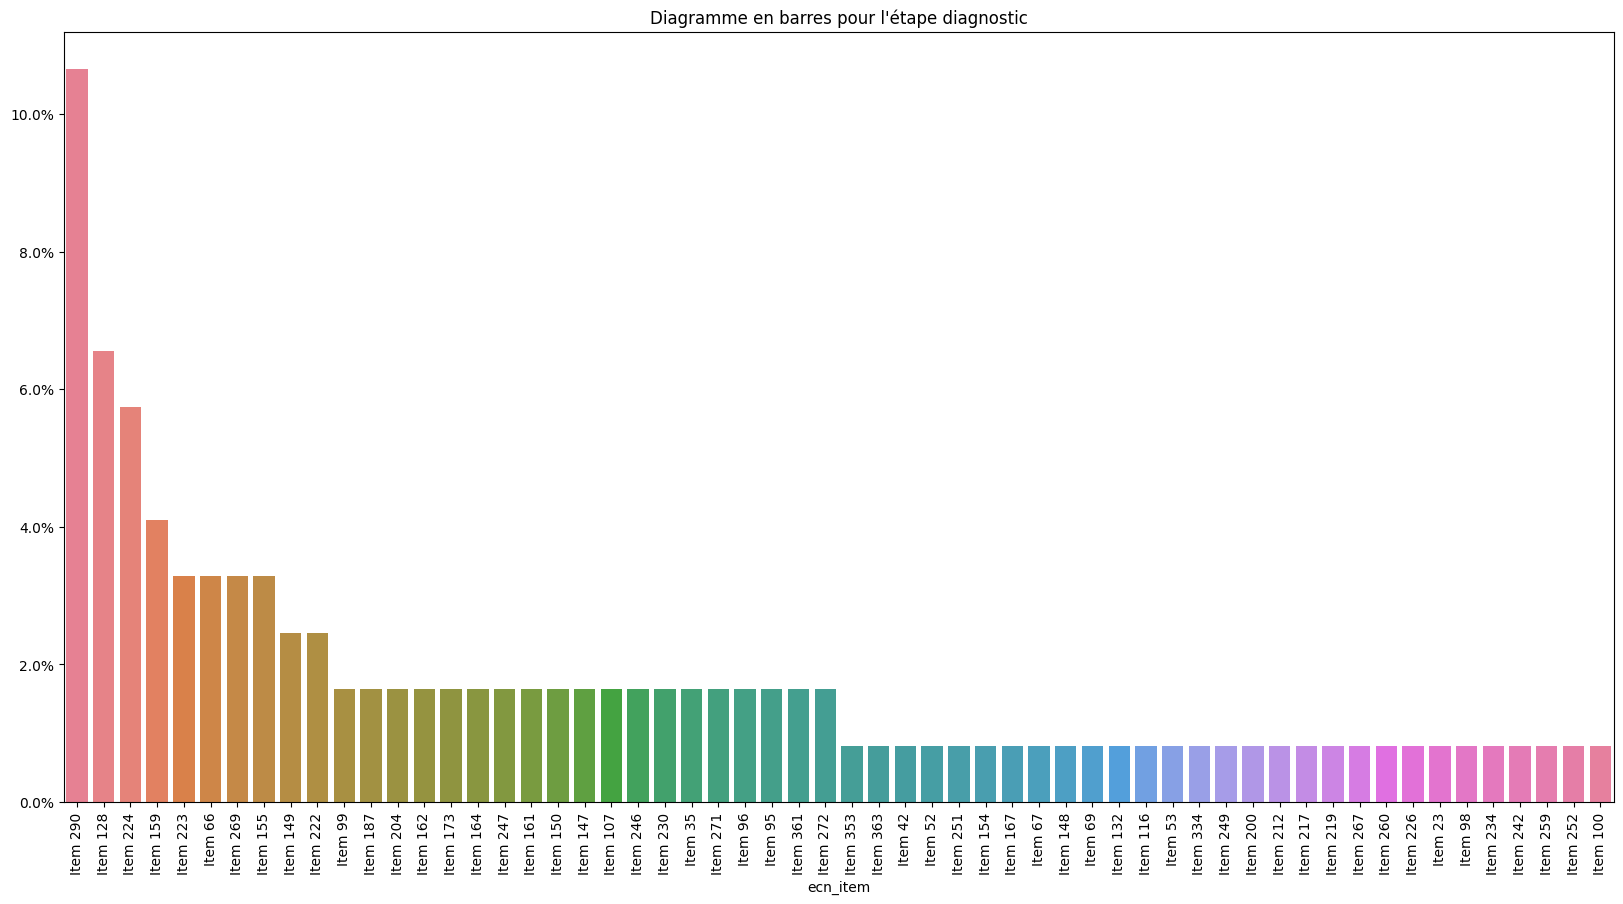

Valeurs absolues : 



ecn_item,Item 290,Item 128,Item 224,Item 159,Item 223,Item 66,Item 269,Item 155,Item 149,Item 222,...,Item 267,Item 260,Item 226,Item 23,Item 98,Item 234,Item 242,Item 259,Item 252,Item 100
diagnostic,13,8,7,5,4,4,4,4,3,3,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 290,Item 128,Item 224,Item 159,Item 223,Item 66,Item 269,Item 155,Item 149,Item 222,...,Item 267,Item 260,Item 226,Item 23,Item 98,Item 234,Item 242,Item 259,Item 252,Item 100
diagnostic,0.106557,0.065574,0.057377,0.040984,0.032787,0.032787,0.032787,0.032787,0.02459,0.02459,...,0.008197,0.008197,0.008197,0.008197,0.008197,0.008197,0.008197,0.008197,0.008197,0.008197


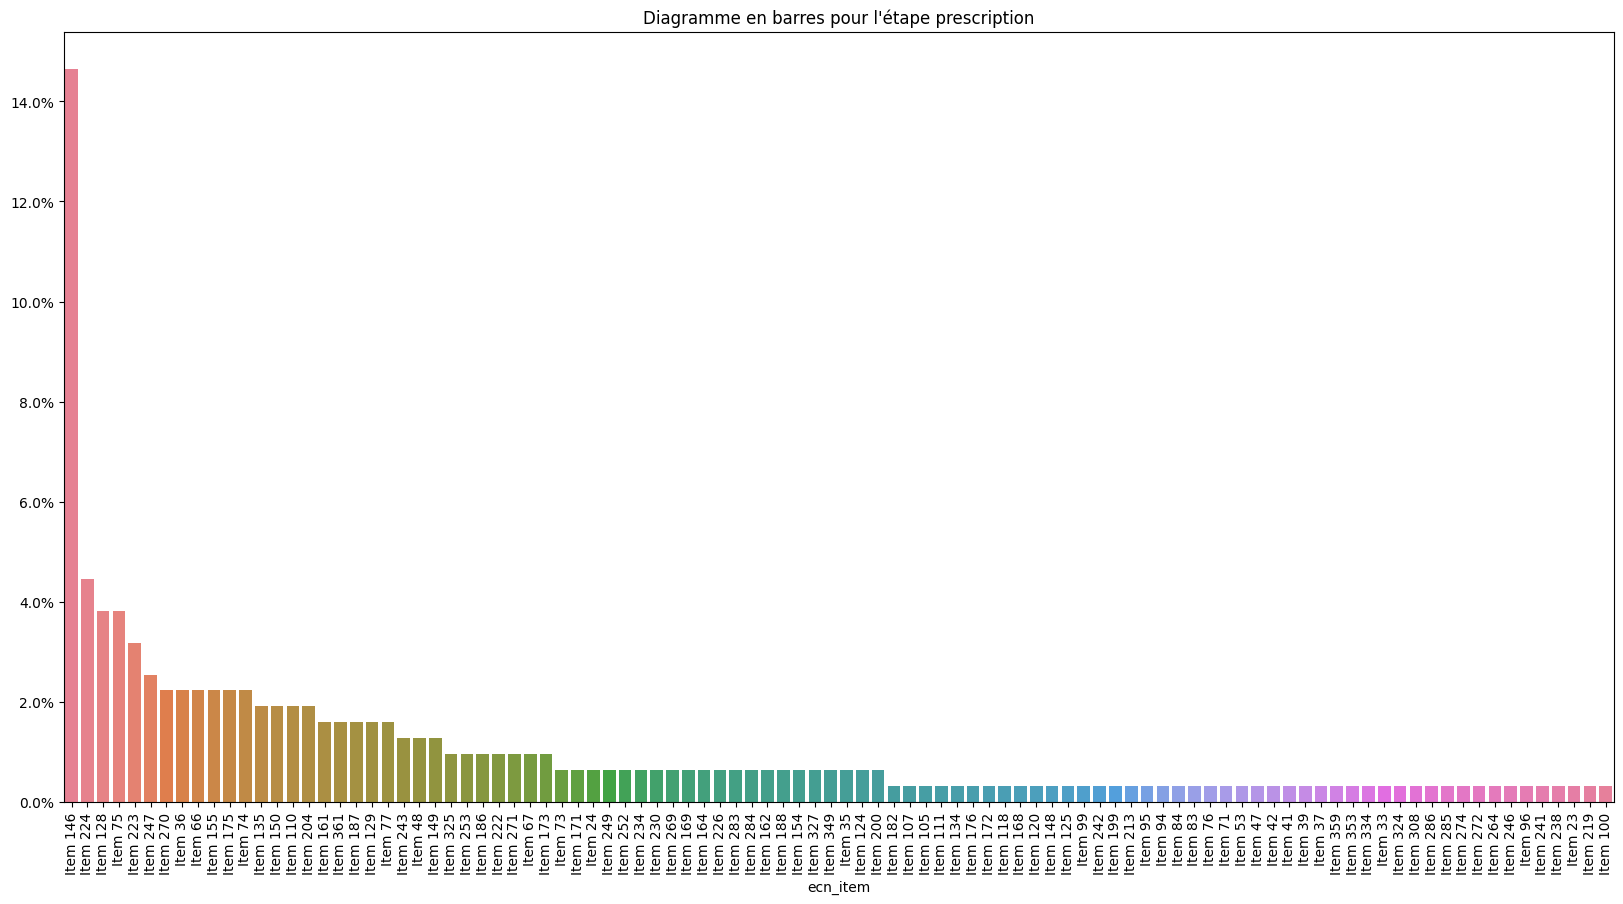

Valeurs absolues : 



ecn_item,Item 146,Item 224,Item 128,Item 75,Item 223,Item 247,Item 270,Item 36,Item 66,Item 155,...,Item 274,Item 272,Item 264,Item 246,Item 96,Item 241,Item 238,Item 23,Item 219,Item 100
prescription,46,14,12,12,10,8,7,7,7,7,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 146,Item 224,Item 128,Item 75,Item 223,Item 247,Item 270,Item 36,Item 66,Item 155,...,Item 274,Item 272,Item 264,Item 246,Item 96,Item 241,Item 238,Item 23,Item 219,Item 100
prescription,0.146497,0.044586,0.038217,0.038217,0.031847,0.025478,0.022293,0.022293,0.022293,0.022293,...,0.003185,0.003185,0.003185,0.003185,0.003185,0.003185,0.003185,0.003185,0.003185,0.003185


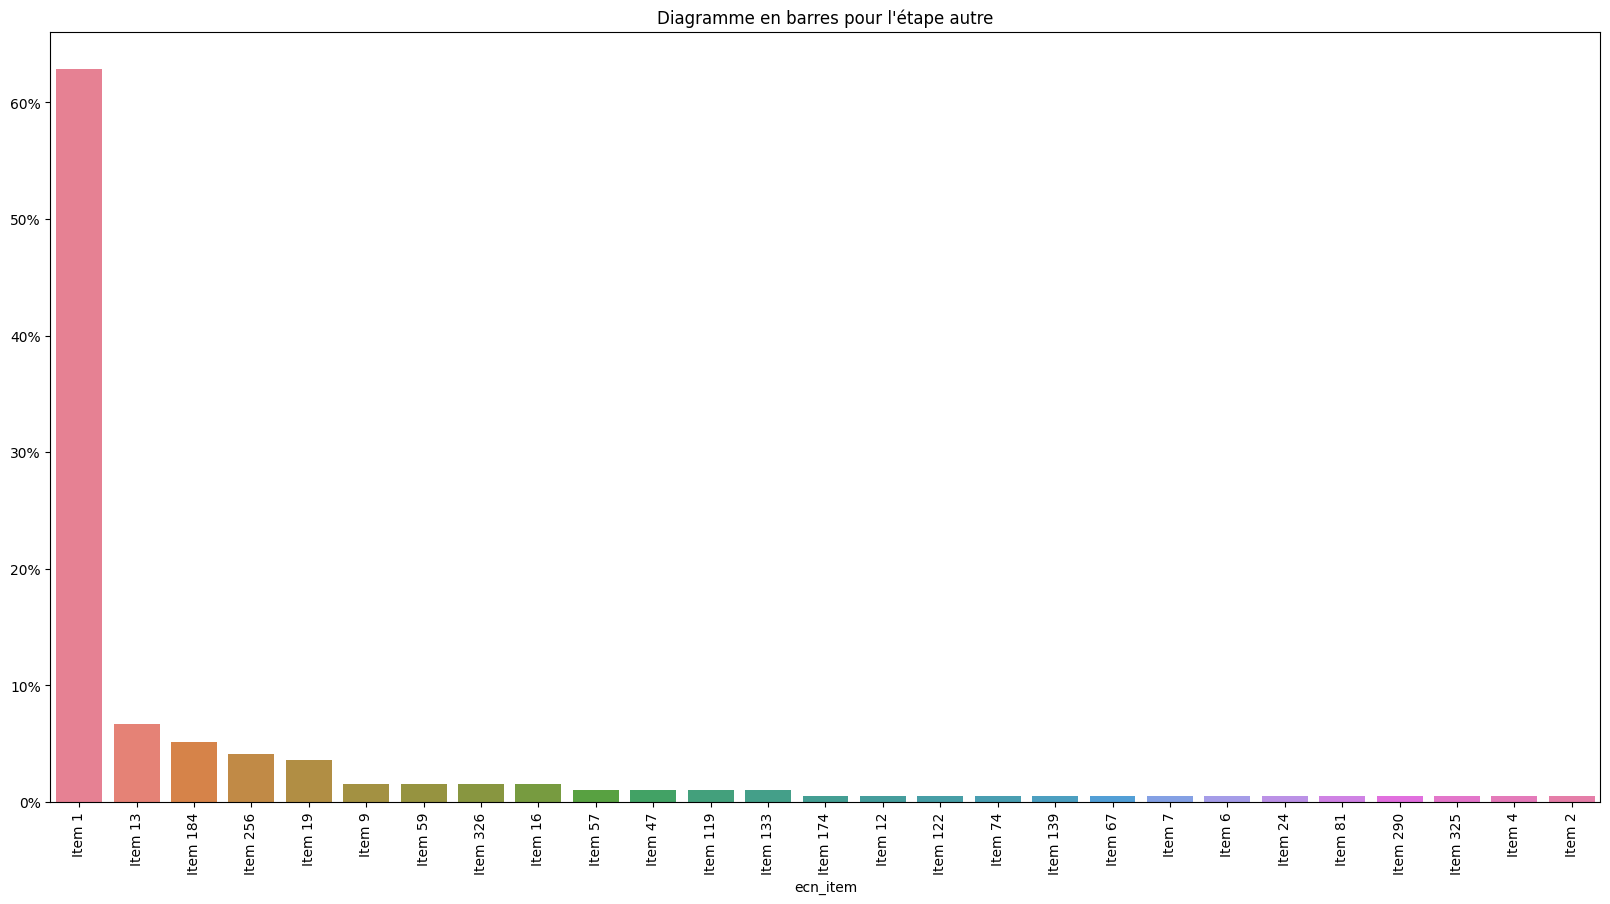

Valeurs absolues : 



ecn_item,Item 1,Item 13,Item 184,Item 256,Item 19,Item 9,Item 59,Item 326,Item 16,Item 57,...,Item 139,Item 67,Item 7,Item 6,Item 24,Item 81,Item 290,Item 325,Item 4,Item 2
autre,122,13,10,8,7,3,3,3,3,2,...,1,1,1,1,1,1,1,1,1,1


Proportions : 



ecn_item,Item 1,Item 13,Item 184,Item 256,Item 19,Item 9,Item 59,Item 326,Item 16,Item 57,...,Item 139,Item 67,Item 7,Item 6,Item 24,Item 81,Item 290,Item 325,Item 4,Item 2
autre,0.628866,0.06701,0.051546,0.041237,0.036082,0.015464,0.015464,0.015464,0.015464,0.010309,...,0.005155,0.005155,0.005155,0.005155,0.005155,0.005155,0.005155,0.005155,0.005155,0.005155


In [3]:
data_gpByItem = data.groupby(['ecn_item']).agg(
    diagnostic = ('step_diag', 'sum'),
    prescription = ('step_PEC_TTT', 'sum'), 
    autre = ('step_autre', 'sum')
)

data_gpByItem = data_gpByItem.transpose()

for i in range(0,data_gpByItem.shape[0]):
    row = data_gpByItem.iloc[[i]]
    row = row.dropna(axis=1, how='all')
    row = row.loc[:, row.iloc[0] != 0]
    row = row[row.columns[row.iloc[0].argsort()[::-1]]]

    rowProp = row.copy()
    rowProp[row.columns] = row[row.columns].div(row[row.columns].sum(axis=1), axis=0)

    plt.figure(figsize=(20, 10))
    sns.barplot(rowProp)
    plt.xticks(rotation=90)
    plt.title(f"Diagramme en barres pour l'étape {data_gpByItem.index[i]}")
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.show()  
    print("Valeurs absolues : \n")
    display(row)
    print("Proportions : \n")
    display(rowProp)
